# Лекция 3. Свёрточные нейронные сети

Демонстрация: обучение CNN на MNIST, визуализация feature maps и Grad-CAM-подобной карты активации.

## 1. Обучение простой CNN на MNIST

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)

import torchvision
import torchvision.transforms as T

transform = T.Compose([T.ToTensor()])
train_ds = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.fc = nn.Linear(32*7*7,10)
    def forward(self,x):
        x = F.relu(self.conv1(x)); x = F.max_pool2d(x,2)
        x = F.relu(self.conv2(x)); x = F.max_pool2d(x,2)
        self.features = x
        x = x.view(x.size(0),-1)
        return self.fc(x)

model = SimpleCNN()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1):
    for i, (xb, yb) in enumerate(train_loader):
        opt.zero_grad()
        out = model(xb)
        loss = F.cross_entropy(out, yb)
        loss.backward(); opt.step()
        if i>=200: break
print("Пример loss после короткого обучения:", loss.item())


100.0%
100.0%
100.0%
100.0%


Пример loss после короткого обучения: 0.15584789216518402


## 2. Визуализация feature maps

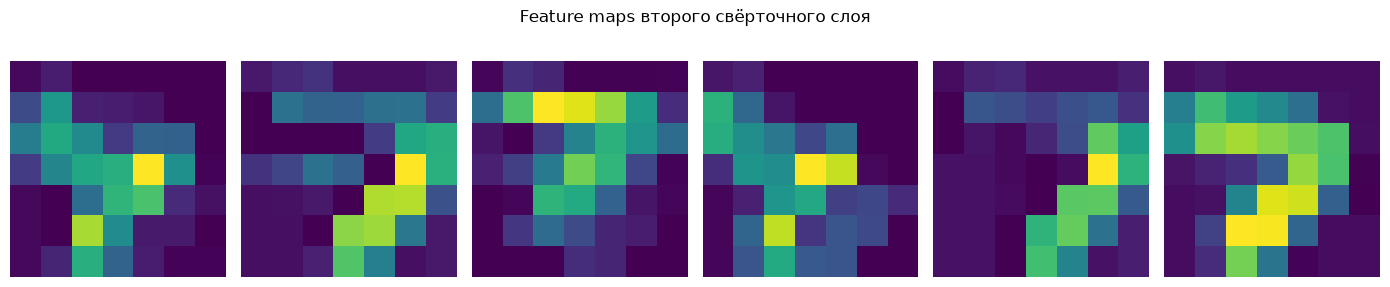

In [2]:

xb, yb = next(iter(train_loader))
_ = model(xb[:1])
fmap = model.features[0].detach().numpy()

fig, axes = plt.subplots(1,6, figsize=(14,3))
for i in range(6):
    axes[i].imshow(fmap[i], cmap='viridis')
    axes[i].axis('off')
plt.suptitle("Feature maps второго свёрточного слоя")
plt.tight_layout()
plt.savefig('output/notebooks/lec3_featuremaps.png', dpi=120)
plt.show()
